# House Price Prediction

A machine learning regression project to predict house sale prices using property features.

## Objective
Build and evaluate regression models for predicting house prices.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# Load the Ames Housing dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
# Check dataset information
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB

Missing Values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

B

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
# Correlation of features with house price
correlation = df.corr()["medv"].sort_values(ascending=False)

print("Correlation with House Price (medv):")
print(correlation)

Correlation with House Price (medv):
medv       1.000000
rm         0.695360
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64


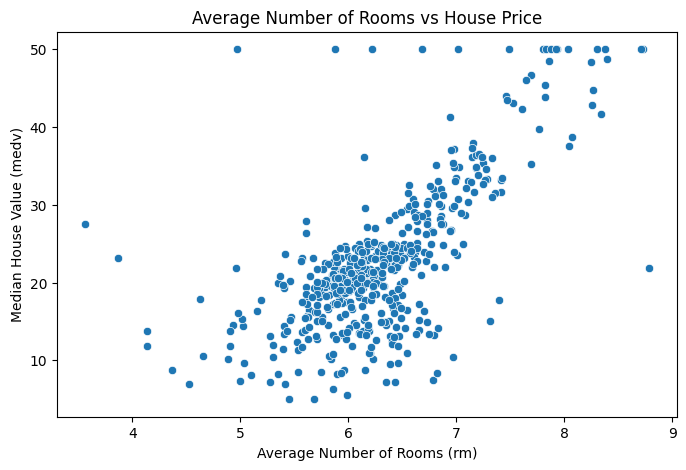

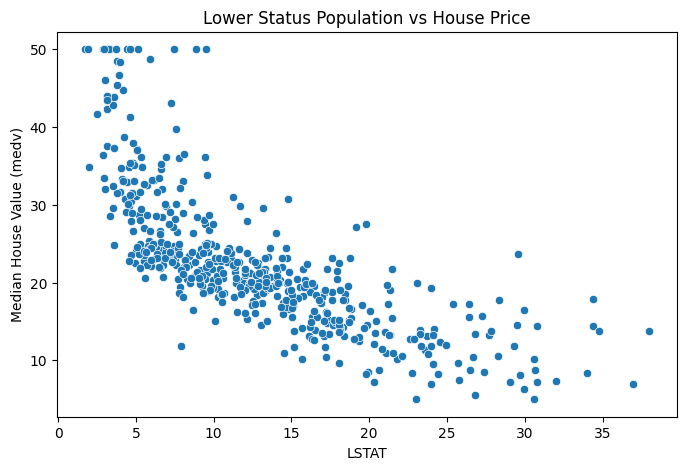

In [ ]:
# Visualize important features against house prices

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="rm", y="medv")
plt.title("Average Number of Rooms vs House Price")
plt.xlabel("Average Number of Rooms (rm)")
plt.ylabel("Median House Value (medv)")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="lstat", y="medv")
plt.title("Lower Status Population vs House Price")
plt.xlabel("LSTAT")
plt.ylabel("Median House Value (medv)")
plt.show()

In [ ]:
# Separate features and target

X = df.drop("medv", axis=1)
y = df["medv"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Features shape: (506, 13)
Target shape: (506,)

Features:
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (404, 13)
Testing data: (102, 13)


In [ ]:
from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
# Make predictions on the test set
y_pred = linear_model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 actual values:")
print(y_test.iloc[:10].values)

First 10 predictions:
[28.99672362 36.02556534 14.81694405 25.03197915 18.76987992 23.25442929
 17.66253818 14.34119    23.01320703 20.63245597]

First 10 actual values:
[23.6 32.4 13.6 22.8 16.1 20.  17.8 14.  19.6 16.8]


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 3.189091965887837


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6687594935356326


In [ ]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 4.928602182665332


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
# Make predictions using Random Forest
rf_pred = rf_model.predict(X_test)

print("First 10 Random Forest predictions:")
print(rf_pred[:10])

print("\nFirst 10 actual values:")
print(y_test.iloc[:10].values)

First 10 Random Forest predictions:
[22.8235 30.814  16.8215 23.5325 16.8455 21.1165 19.4935 15.7155 21.1475
 21.0105]

First 10 actual values:
[23.6 32.4 13.6 22.8 16.1 20.  17.8 14.  19.6 16.8]


In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = root_mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Performance
-------------------------
MAE : 2.0413137254901943
RMSE: 2.917224938728114
R²  : 0.8839525117021145


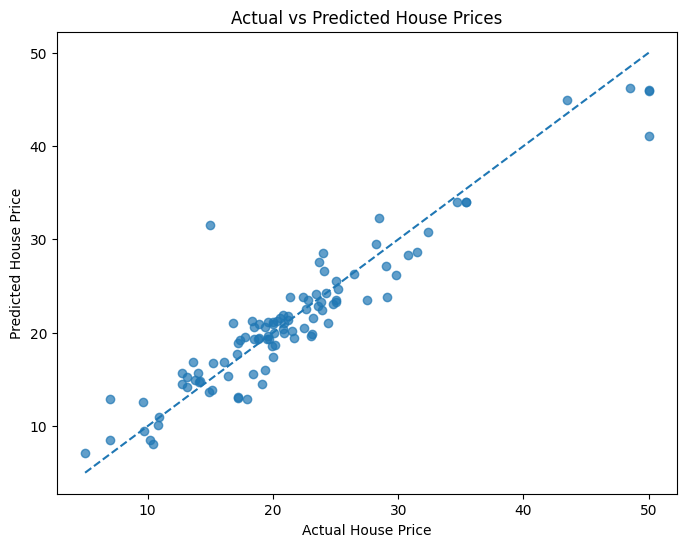

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.7)

# Perfect prediction line
min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [ ]:
# Get feature importance from Random Forest
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
rm         0.492309
lstat      0.323469
dis        0.056308
crim       0.038540
nox        0.015979
ptratio    0.015956
tax        0.015470
age        0.015199
b          0.012431
indus      0.007021
rad        0.004135
zn         0.001891
chas       0.001292
dtype: float64


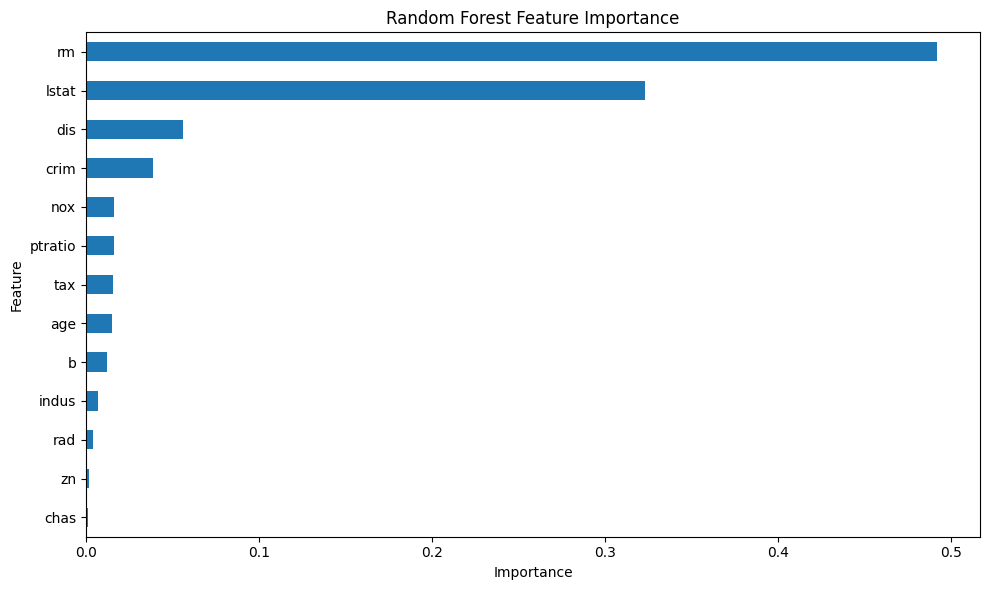

In [ ]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# Compare model performance

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2 Score": [r2, rf_r2]
})

results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.189092,4.928602,0.668759
1,Random Forest,2.041314,2.917225,0.883953


## Final Results

Two regression models were trained and evaluated on the same test set.

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Linear Regression | 3.1891 | 4.9286 | 0.6688 |
| Random Forest | 2.0413 | 2.9172 | 0.8840 |

### Best Model

The **Random Forest Regressor** achieved the best performance with:

- **MAE:** 2.0413
- **RMSE:** 2.9172
- **R² Score:** 0.8840

The Random Forest substantially outperformed the Linear Regression baseline, demonstrating its ability to capture non-linear relationships and interactions between the housing features.


In [ ]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [23]:
# Example prediction using one house from the test set

sample_house = X_test.iloc[[0]]

predicted_price = rf_model.predict(sample_house)[0]
actual_price = y_test.iloc[0]

print("Predicted House Price:", round(predicted_price, 2))
print("Actual House Price:", actual_price)
print("Prediction Error:", round(abs(predicted_price - actual_price), 2))

Predicted House Price: 22.82
Actual House Price: 23.6
Prediction Error: 0.78


## Conclusion

In this project, machine learning regression models were developed to predict house prices.

### Key Results

- Linear Regression achieved an R² score of **0.6688**.
- Random Forest achieved an R² score of **0.8840**.
- Random Forest reduced MAE from **3.1891** to **2.0413**.
- Random Forest reduced RMSE from **4.9286** to **2.9172**.

### Final Model

The **Random Forest Regressor** was selected as the final model because it achieved substantially better performance on the unseen test set.

### Key Learning Outcomes

- Performed exploratory data analysis.
- Analyzed feature-target correlations.
- Prepared data for regression.
- Compared Linear Regression and Random Forest.
- Evaluated models using MAE, RMSE, and R².
- Analyzed Random Forest feature importance.
- Saved the trained model for future use.

This project demonstrates an end-to-end machine learning workflow, from data exploration and preprocessing to model training, evaluation, comparison, and model persistence.
